#### SVMs

Support Vector Machines are a way to find a split in the data that has a soft boundary rather than a hard boundary.  

In [85]:
# import libraries that we need

import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

from matplotlib import colors
import seaborn as sns

import scipy.stats as stats

from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.inspection import DecisionBoundaryDisplay

In [86]:
# Visualizing confusion matrices for each classifier
# Here's another function for plotting the confusion matrix
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [87]:
# read in the bcancer data
bcancer = pd.read_csv("https://webpages.charlotte.edu/mschuck1/classes/DTSC2301/Data/BreastCancer.csv", na_values=['NA'])
bcancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Diagnosis       569 non-null    object 
 1   Radius          569 non-null    float64
 2   Texture         569 non-null    float64
 3   Perimeter       569 non-null    float64
 4   Area            569 non-null    float64
 5   Smoothness      569 non-null    float64
 6   Compactness     569 non-null    float64
 7   Concavity       569 non-null    float64
 8   Concave Points  569 non-null    float64
 9   Symmetry        569 non-null    float64
dtypes: float64(9), object(1)
memory usage: 44.6+ KB


In [ ]:
feature_names = ['Concavity','Texture','Radius','Area']
target_names = ['B','M']

# Choose the features X and target y
X=bcancer[['Concavity','Texture','Radius','Area']]
y = bcancer['Diagnosis']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a decision tree classifier
dtree = DecisionTreeClassifier(random_state=420)

# Train the classifier
dtree.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtree.predict(X_test)

# get the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Evaluate the model with out of sample prediction
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

[[61 10]
 [ 7 36]]
Accuracy: 0.8508771929824561


Accuracy: 0.9385964912280702


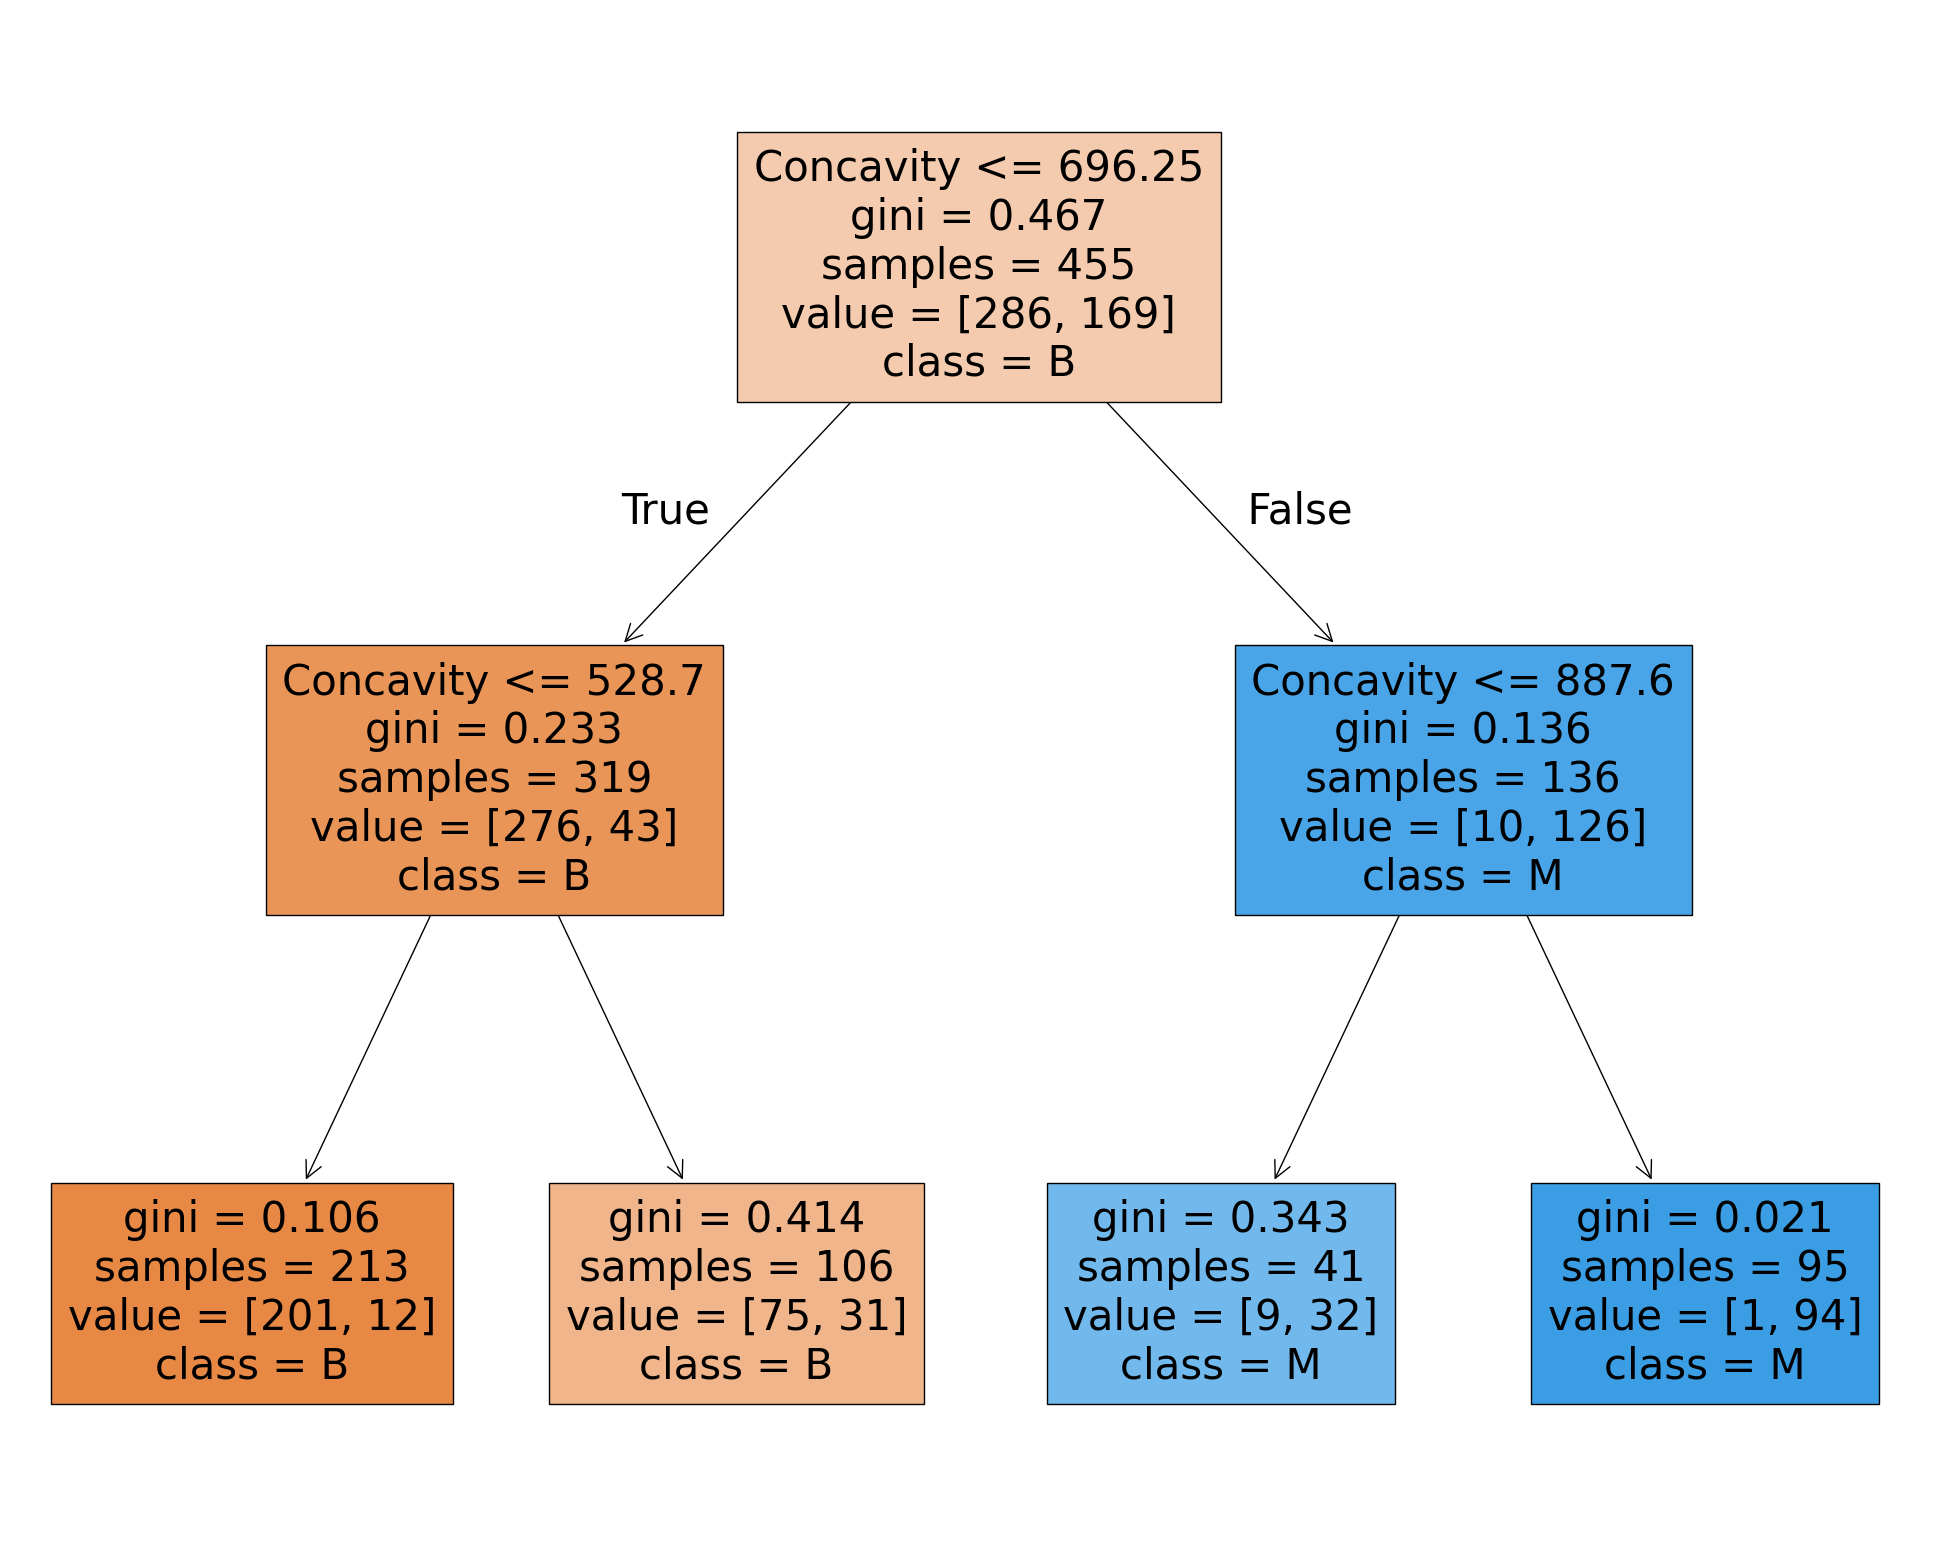

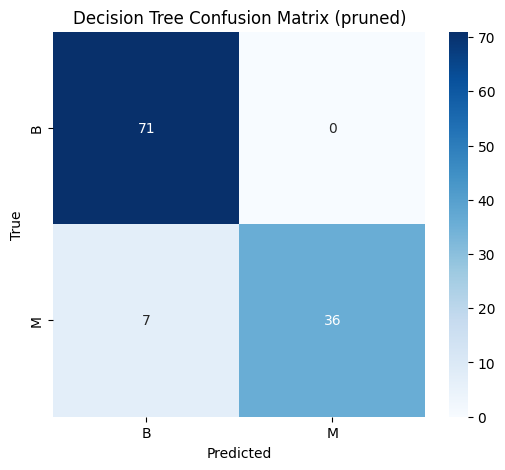

In [ ]:
dt_pre_pruned2 = DecisionTreeClassifier(max_depth=2, min_samples_split=5, min_samples_leaf=2)

# Train the model
dt_pre_pruned2.fit(X_train, y_train)

fig = plt.figure(figsize=(25,20))
tree.plot_tree(dt_pre_pruned2,
                   feature_names=['Concavity','Texture','Radius','Area'],
                   class_names=['B','M'],
                   filled=True)

y_pred = dt_pre_pruned2.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')




plot_confusion_matrix(y_test, y_pred, 'Decision Tree Confusion Matrix (pruned)')

So this is a better tree by far than the previous.  We can also clearly see which of the features is important for this classification.

### Support Vector Machines (SVM)
We are going to start with an SVM that uses a linear boundary.  In the code below our tolerance for the boundary is defined by C.  The default is 1.0 as shown.

Below we will use 'Texture' and 'Area' since that is a bit easier to see.

Linear SVM accuracy: 93.86%


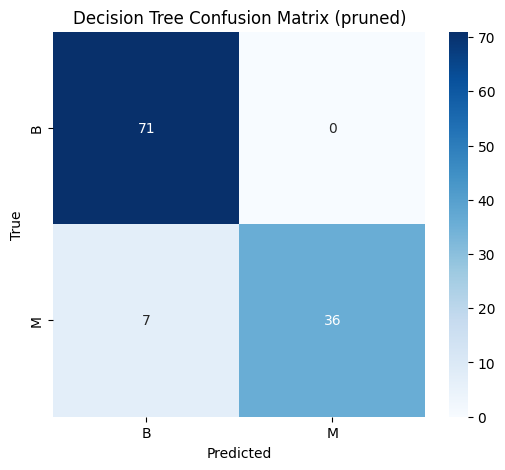

In [90]:
# Redefine the Xmatrix so we get something we can see
X=bcancer[['Texture','Area']]
y = bcancer['Diagnosis']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 1. Linear Kernel SVM

# Create a linear kernel SVM model
linear_svm = SVC(kernel='linear', C=1.0)

# Train the model on the training data
linear_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_svm.predict(X_test)

# Calculate accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear SVM accuracy: {accuracy_linear * 100:.2f}%")

plot_confusion_matrix(y_test, y_pred_linear, 'Decision Tree Confusion Matrix (pruned)')

The support vector machine we used above creates a linear decision boundary because we set the kernel to be 'linear'.  

The support vector machine we used above creates a linear decision boundary.  

Below we will look at the Radial Basis Function (RBF) Kernel which allows for distance based decision boundaries.  

RBF Kernel SVM accuracy: 92.11%


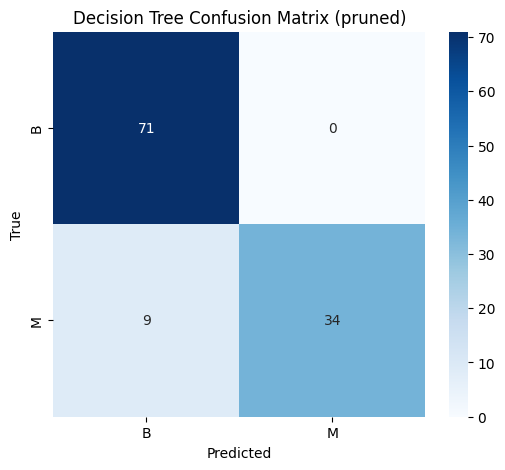

In [91]:

# Create an RBF kernel SVM model
rbf_svm = SVC(kernel='rbf')

# Train the model on the training data
rbf_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rbf = rbf_svm.predict(X_test)

# Calculate accuracy
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"RBF Kernel SVM accuracy: {accuracy_rbf * 100:.2f}%")

plot_confusion_matrix(y_test, y_pred_rbf, 'Decision Tree Confusion Matrix (pruned)')

The *rbf* kernel that we use here is a radial basis function and as the name suggests it is a function of $$exp^d$$ where $d$ is the Euclidean distance/radial distance between two vectors.  This allows for the creation of decision boundaries that are based upon the 


[<https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html>]

[<https://en.wikipedia.org/wiki/Radial_basis_function_kernel>]

So far we have just used a single split to evaluate the performance of our models.  Let's do some cross validation of our models.  And we are lucky that this is made easy for us by having a function that does cross-validation and accuracy in one fell swoop.  That function is *cross_val_score*.

In [92]:

# Cross-validation for linear kernel
cv_scores_linear = cross_val_score(linear_svm, X, y, cv=5)  # 5-fold cross-validation
print(f"Linear Kernel SVM cross-validation accuracy: {cv_scores_linear.mean() * 100:.2f}%")

# Cross-validation for RBF kernel
cv_scores_rbf = cross_val_score(rbf_svm, X, y, cv=5)  # 5-fold cross-validation
print(f"RBF Kernel SVM cross-validation accuracy: {cv_scores_rbf.mean() * 100:.2f}%")

#

Linear Kernel SVM cross-validation accuracy: 88.58%
RBF Kernel SVM cross-validation accuracy: 88.76%


### Tasks 

1.   Using Texture, Radius, Area, Compactness and Smoothness, run 8 fold cross validation for the following models: logistic regression, SVM with linear kernel, SVM with RBF kernel, decision tree with depth of 3, decision tree with depth of 5.  Report which method did performed the best.  

2. Write a paragraph summarizing the analysis you did in Task 1 and explaining the model to a classmate.  Include a visualization of the performance of the model.

3. Find code to plot the boundary of an svm and plot the boundary for a RBF kernel SVM with C=1.0, C=0.1 and C=10.0 using features 'Area' and 'Texture'.  Small C: Creates a wider margin and allows more misclassifications, leading to a simpler, more generalized model.  Large C: Penalizes misclassifications heavily, leading to a smaller margin and a potentially overfit model that tries to classify all training points correctly.